# E. coli batch: forward simulation

Run all six steps to simulate the configured process and reproduce `outputs/trajectories.csv`, `trajectories.png`, and `trajectories.svg`. CSV files open in spreadsheet applications. Only `inputs/case.json`, `mechanism.json`, and `thermo.json` are required.

The current inputs select the native mass/density volume policy. Change inputs to choose another supported policy; plots are model predictions. All notebook steps are forward simulation and output generation.


## Step 1: Select input and output folders


In [1]:
# STEP 1: Select input and output folders
# Run each cell in order with Shift+Enter, or use Run All.
# Change example_dir for a copied case. Exports replace matching files in EXPORT_DIR;
# choose another folder to preserve a previous run, or set WRITE_ARTIFACTS=False.
from pathlib import Path
import csv
import json
import sys
import numpy as np
import matplotlib.pyplot as plt

repo_root = next((path for path in (Path.cwd(), *Path.cwd().parents)
                  if (path / "PharmaPy").is_dir()), None)
if repo_root is None:
    raise ValueError("Set repo_root to your PharmaPy checkout before running this cell")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
from PharmaPy.Bioreactors import build_bioreactor
from PharmaPy.Bioreactors.input_format import normalize_forward_inputs

example_dir = repo_root / "examples/bioreactors/batch_ecoli_dfba"
input_dir = example_dir / "inputs"
thermo_path = input_dir / "thermo.json"
EXPORT_DIR = example_dir / "outputs"
WRITE_ARTIFACTS = True


## Step 2: Load and edit forward-simulation inputs


In [2]:
# STEP 2: Load and edit forward-simulation inputs
# Edit case.json, mechanism.json and thermo.json, or edit these dictionaries below.
# Keep species identifiers and initial mass/volume/density consistent. Input units
# are declared in the JSON files; recipe times use numerics.step.unit.
# Rerun this and all following cells after changing inputs.
case = json.loads((input_dir / "case.json").read_text())
config = json.loads((input_dir / "mechanism.json").read_text())
# case["operation"]["volume_policy"] = "working-volume"
# case["operation"]["runtime"]["value"] = 6.0
print(json.dumps(case, indent=2))


{
  "schema_version": 2,
  "biology": {
    "conditions": {}
  },
  "numerics": {
    "backend": "scipy",
    "step": {
      "unit": "h",
      "value": 0.05
    },
    "relative_tolerance": 1e-08,
    "absolute_tolerance": 1e-11,
    "maximum_step": {
      "unit": "s",
      "value": 30.0
    },
    "jacobian_relative_step": 1e-06,
    "jacobian_state_scale": 1e-06
  },
  "operation": {
    "carrier_density_kg_l": 1.0,
    "carrier_species": "water",
    "initial_mass_kg": 1.0,
    "initial_volume": {
      "unit": "L",
      "value": 1.0
    },
    "mode": "batch",
    "runtime": {
      "unit": "h",
      "value": 10.0
    },
    "temperature_k": null,
    "volume_policy": "native"
  },
  "recipe": {
    "name": "batch",
    "require_complete_inputs": false
  },
  "$comment": "Schema 2. Fill the shared template; see doc/online_docs/bioreactors/templates/guide.json."
}


## Step 3: Run the native forward simulation


In [3]:
# STEP 3: Run the native forward simulation
# Run to construct a fresh reactor and execute its complete configured schedule.
# histories contains every segment, including both sides of material additions.
assembly = build_bioreactor(case, config, thermo_path)
unit = assembly.unit
histories = assembly.solve(verbose=False)
print("Native reactor:", type(unit).__name__)
print("Recorded segments:", len(histories))


Native reactor: BatchReactor
Recorded segments: 1


## Step 4: Build the trajectory table


In [4]:
# STEP 4: Build the trajectory table
# Run to convert native inventories using each recorded reactor volume.
# Time and amount units appear in column names; CHO species columns are mmol/L.
# Duplicate event times retain pre/post-addition rows in segment order.
names = tuple(normalize_forward_inputs(case, config)[1]["model"]["state_ids"])
rows = []
for segment_index, result in enumerate(histories):
    mass_history = np.asarray(result.mass_j_liquid0)
    biomass_history = np.asarray(result.biomass_kg_liquid0)
    for i in range(len(result.time)):
        mass = mass_history[i]
        volume = np.asarray(result.vessel_vol).reshape(-1)[i]
        row = {"time_h": result.time[i] / 3600.0, "segment_index": segment_index}
        for name in names:
            j = list(assembly.phase.name_species).index(name)
            row[f"{name}_mmol_l"] = mass[j] / assembly.phase.mw[j] * 1e6 / (volume * 1000.0)
        row["biomass_gdw_l"] = biomass_history[i] / volume
        rows.append(row)

print("Recorded rows:", len(rows))
print("Final row:", rows[-1])


Recorded rows: 201
Final row: {'time_h': np.float64(10.0), 'segment_index': 0, 'glucose_mmol_l': np.float64(0.0), 'acetate_mmol_l': np.float64(0.0), 'oxygen_mmol_l': np.float64(0.20537771582888445), 'biomass_gdw_l': np.float64(0.9001142076014625)}


## Step 5: Plot the simulated trajectories


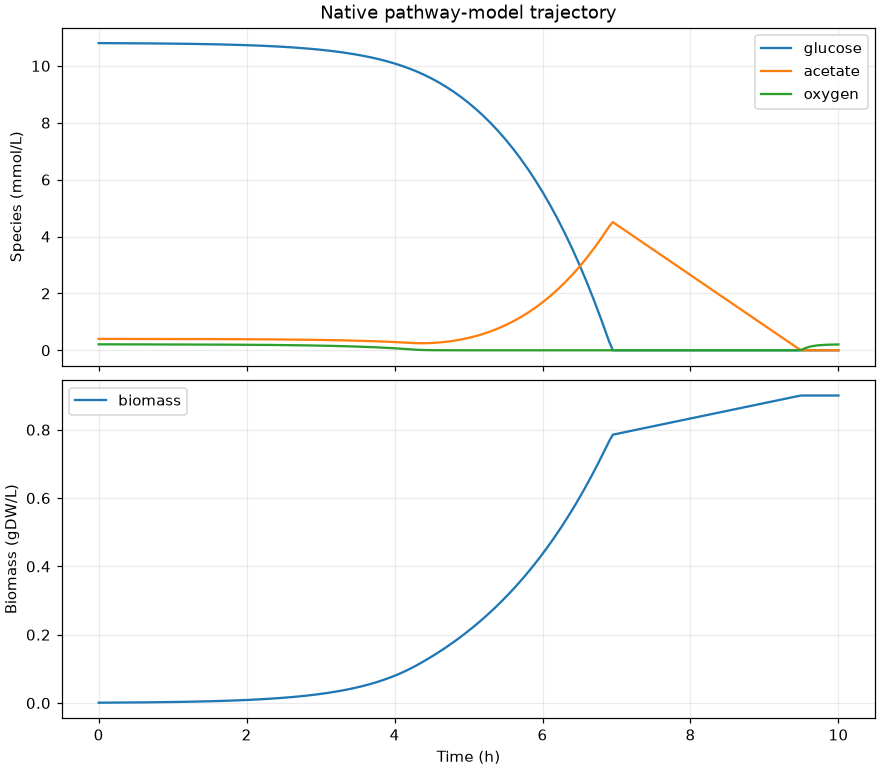

In [5]:
# STEP 5: Plot the simulated trajectories
# Run to display the figure. Edit the species selection, axes and labels here.
# Curves use the same rows and recorded volumes as the exported trajectory table.
figure, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True, constrained_layout=True)
time = [row["time_h"] for row in rows]
for name in names:
    axes[0].plot(time, [row[f"{name}_mmol_l"] for row in rows], label=name)
axes[1].plot(time, [row["biomass_gdw_l"] for row in rows], label="biomass")
axes[0].set(ylabel="Species (mmol/L)", title="Native pathway-model trajectory")
axes[1].set(xlabel="Time (h)", ylabel="Biomass (gDW/L)")
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend()
plt.show()


## Step 6: Export the trajectory spreadsheet and figures


In [6]:
# STEP 6: Export the trajectory spreadsheet and figures
# Run to save a spreadsheet-compatible CSV plus PNG and SVG figures.
# Files in EXPORT_DIR with these names are replaced; no fitting or comparison runs.
if WRITE_ARTIFACTS:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    with (EXPORT_DIR / "trajectories.csv").open("w", newline="") as stream:
        writer = csv.DictWriter(stream, fieldnames=list(rows[0]), lineterminator="\n")
        writer.writeheader()
        writer.writerows(rows)
    figure.savefig(EXPORT_DIR / "trajectories.png", dpi=180)
    figure.savefig(EXPORT_DIR / "trajectories.svg")
    print("Saved trajectories.csv, trajectories.png and trajectories.svg to", EXPORT_DIR)
else:
    print("Export disabled; trajectories and figure remain in memory.")


Saved trajectories.csv, trajectories.png and trajectories.svg to /Users/qhuckaba/Desktop/Bioreactor Branch/examples/bioreactors/batch_ecoli_dfba/outputs
